# Reconstruction on anticyclonic and cyclonic structures


In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc, drifters_structure
from diagnosis import generate_0_15m_coloc_dataframe, sel_structure, compute_variance_groupby, compute_variance, prepared_alti
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, structure
depthcolor = {0:'navy', 15:'green', 50:'yellowgreen', 100:'yellow'}

In [59]:
def plot_one_axis(df_, ax):
    kwargs = dict(hatch="/",width = 0.8, capsize=2)
    plt.rcParams["hatch.color"] = c0['cor']
    
    plt.rcParams["hatch.color"] = c0['cor']
    ax.bar(0, df_.X_acc_cor, color = c0['acc'], yerr =df_['er__X_acc_cor'], **kwargs)

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(1, df_.X_acc_ggd, color = c0['acc'],  yerr =df_['er__X_acc_ggd'], **kwargs)

    plt.rcParams["hatch.color"] = c0['cor']
    ax.bar(2, df_.X_cor_ggd, color = c0['ggd'], yerr =df_['er__X_cor_ggd'], **kwargs)

    #plt.rcParams["hatch.color"] = c0['cor']
    #ax.bar(3, df_.X_cor_wd, color = c0['wd'], yerr =df_['er__X_cor_wd'], **kwargs)
    
    #plt.rcParams["hatch.color"] = c0['acc']
    #ax.bar(4, df_.X_acc_wd, color = c0['wd'], yerr =df_['er__X_acc_wd'], **kwargs)
        
    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(5, df_.X_ggd_wd, color = c0['wd'], yerr =df_['er__X_ggd_wd'], **kwargs)
    
    ax.grid()
    ax.set_ylabel(rf'Paired contributions [$\gamma^2$]')
    ax.set_xticks([0, 1, 2], ['Inertial pair', 'Pressure gradient term \n - Coriolis acceleration pair', 'Geostrophic pair'], rotation=45, ha='right')
    print_labels(df_, ax)


In [4]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    from matplotlib import colors
    da.plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0, add_colorbar=False,)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    return fig, ax, ax_histx, ax_histy
    #fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

def plot_join_pdfs_one(ds, x, y, binx=100, biny=100, ax=None):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x], coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    
    from matplotlib import colors
    da.where(da!=0).plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ax.grid()
    


## Data 

In [30]:
df0, df15 = generate_0_15m_coloc_dataframe('LF', DT=12)

12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [31]:
dfs = prepared_alti(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'xarray_diff' ,
        alti_diff_method_param = '')

def concat(df, dfs, from_='mano'):
    df = pd.concat([df, dfs[['vorticity_etaf', 'strain_s_etaf', 'strain_n_etaf',]]], axis=1).dropna()
    df['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
    fo = df.f.mean()
    # From computation
    if from_ =='mano' :
        df['strain_f'] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
        df['strain'] = df.strain_f*df.f#.assign_attrs({'long_name':r'$\sigma/|f|$'})
        df['vorticity'] = df.vorticity_etaf*df.f#.assign_attrs({'long_name':r'$\zeta/f$'})
        df['vorticity_f'] = df.vorticity_etaf#.assign_attrs({'long_name':r'$\zeta/f$'})
        df['omega'] = df.strain**2 - df.vorticity**2
    # From duacs
    elif from_ =='duacs' :
        df['strain_f'] = dfs.duacs_strain/df.f
        df['strain'] = df.strain_f*df.f
        df['vorticity_f'] = dfs.duacs_relative_vorticity
        df['vorticity'] = df.vorticity_f*df.f
        df['omega'] = df.strain**2 - df.vorticity**2
    return df
df0 = concat(df0, dfs)
df15 = concat(df15, dfs)


## Cyclogeostrophy (not looking at Ekman term as depend on depth)

In [ ]:
# Cyclone
dfc = pd.concat([sel_structure(df0, **structure[c]) for c in [k for k in structure if 'Cyclone' in k]])
dsc = dfc.to_xarray()
dsc['id_comb'] = dsc['id_comb'].isel(row_number=0)
dsc = dsc.set_coords('id_comb').expand_dims('id_comb')
dmc = compute_variance(dsc, compute_error='centrallimit')/U2

# Anticyclone
dfa = pd.concat([sel_structure(df0, **structure[c]) for c in [k for k in structure if 'nticyclone' in k]])
dsa = dfa.to_xarray()
dsa['id_comb'] = dsa['id_comb'].isel(row_number=0)
dsa = dsa.set_coords('id_comb').expand_dims('id_comb')
dma = compute_variance(dsa, compute_error='centrallimit')/U2

# All
ds = df0.to_xarray()
ds['id_comb'] = ds['id_comb'].isel(row_number=0)
ds = ds.set_coords('id_comb').expand_dims('id_comb')
dm = compute_variance(ds, compute_error='centrallimit')/U2

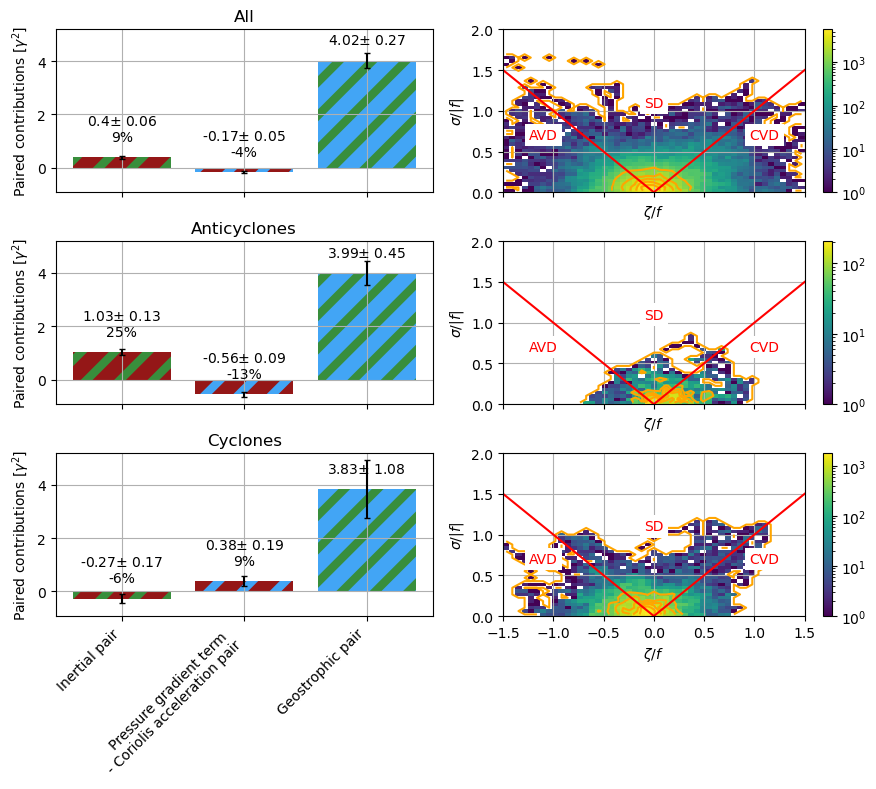

In [71]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6

fig, axs = plt.subplots(3, 2, frameon=False, figsize=(9, 8), sharex='col', sharey='col')

axs =axs.T.flatten()

# X_
plot_one_axis(dm, axs[0])
axs[0].set_title('All')
plot_one_axis(dma, axs[1])
axs[1].set_title('Anticyclones')
plot_one_axis(dmc, axs[2])
axs[2].set_title('Cyclones')

# Vorticity-strain diagram

ax=axs[3]
plot_join_pdfs_one(df0, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')
kwa = dict(c='r', bbox=dict(facecolor="w", edgecolor="none", pad=3.0), va='center', ha='center')


ax=axs[4]
plot_join_pdfs_one(dfc, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')
ax.set_ylim(0, 1.25)

ax=axs[5]
plot_join_pdfs_one(dfa, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

for ax in axs[3:]:
    ax.annotate('AVD', (-1.1, 0.7), **kwa)
    ax.annotate('SD', (0, 1.1), **kwa)
    ax.annotate('CVD', (1.1, 0.7), **kwa)


fig.tight_layout()


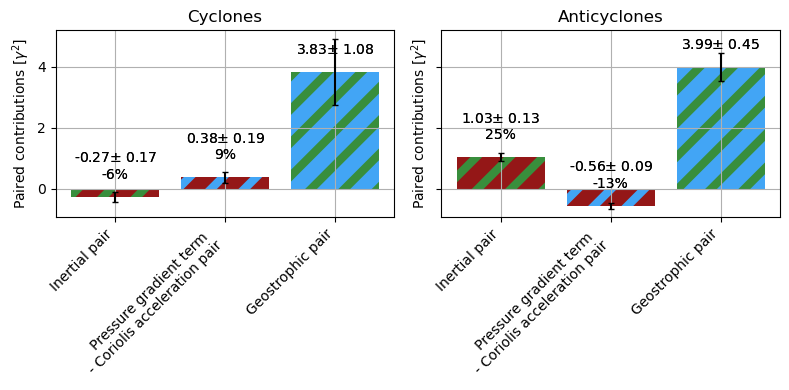

In [61]:
def print_labels(df, ax):
    S = df.X_cor_ggd
    l = ['X_acc_cor', 'X_acc_ggd', 'X_cor_ggd']
    for i in [0, 1, 2] :
        X=l[i]
        label = rf"{np.round(df[X].values[0], 2)}"+rf"$\pm$ {np.round(df['er__' + X].values[0], 2)}"
        if i in [0, 1] :
            label = label + '\n' + f"{int(df[X].values[0]/S*100)}%"
        ax.text(i,
                df[X].values + 0.5,
                label,
                horizontalalignment="center",
                verticalalignment="bottom",
                rotation = 0
            )



fig, axs = plt.subplots(1, 2, frameon=False, figsize=(8, 4), sharey='row')

axs =axs.flatten()

# X_
plot_one_axis(dmc, axs[0])
print_labels(dmc, axs[0])
axs[0].set_title('Cyclones')
plot_one_axis(dma, axs[1])
print_labels(dma, axs[1])
axs[1].set_title('Anticyclones')

fig.tight_layout()


# Diagram vorticity/strain

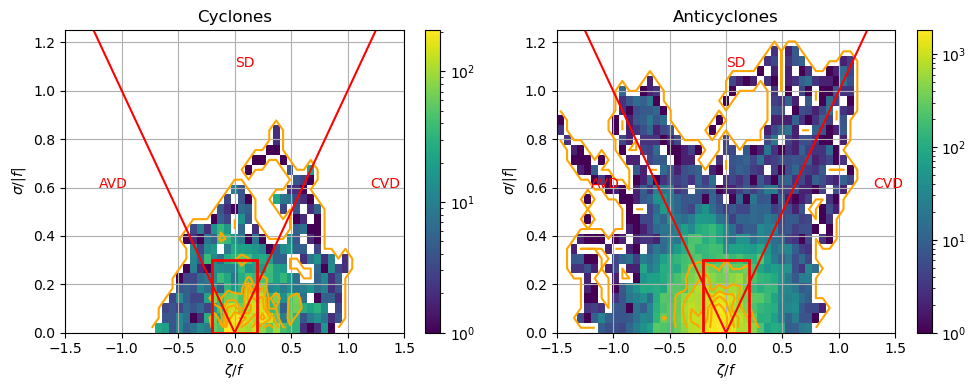

In [35]:
fig, axs = plt.subplots(1, 2, figsize =(10, 4), frameon=False)

ax=axs[0]
plot_join_pdfs_one(dfc, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 1.1), c='r')
ax.annotate('CVD', (1.2, 0.6), c='r')

ax.set_title('Cyclones')
ax.set_ylim(0, 1.25)

ax=axs[1]
plot_join_pdfs_one(dfa, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 1.1), c='r')
ax.annotate('CVD', (1.3, 0.6), c='r')

ax.set_title('Anticyclones')

ax.set_ylim(0, 1.25)

fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', f'15m_diagvortstrain_DT{DT}.png'))

In [ ]:
fig, axs = plt.subplots(1, 2, figsize =(10, 4), frameon=False)

ax=axs[0]
plot_join_pdfs_one(dfc, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 1.1), c='r')
ax.annotate('CVD', (1.2, 0.6), c='r')

ax.set_title('Cyclones')
ax.set_ylim(0, 1.25)

ax=axs[1]
plot_join_pdfs_one(dfa, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 1.1), c='r')
ax.annotate('CVD', (1.3, 0.6), c='r')

ax.set_title('Anticyclones')

ax.set_ylim(0, 1.25)

fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', f'15m_diagvortstrain_DT{DT}.png'))